In [ ]:
# ------------------------------------------------------------
# INSTALL REQUIRED LIBRARIES
# ------------------------------------------------------------
# pygame         → Used for creating and visualizing the grid-world environment
# numpy          → Used for numerical operations and storing value/policy tables
# pillow (PIL)   → Used for loading and displaying saved images
# pyvirtualdisplay → Creates a virtual screen so Pygame can run in Google Colab

!pip install pygame numpy pillow pyvirtualdisplay

In [ ]:
# ------------------------------------------------------------
# INSTALL XVFB (X Virtual Frame Buffer)
# ------------------------------------------------------------
# Required to run graphical applications (like Pygame)
# in a headless environment such as Google Colab

!apt-get update
!apt-get install -y xvfb

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,615 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,205 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,869 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 http://ar

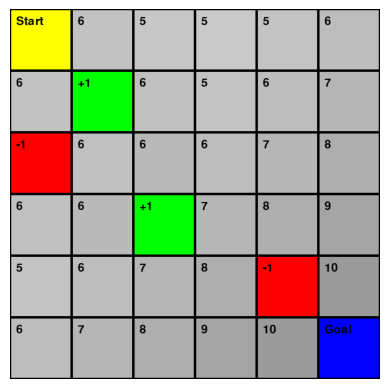

In [ ]:
import numpy as np
import pygame
from PIL import Image
from pyvirtualdisplay import Display
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SETUP VIRTUAL DISPLAY (needed to run Pygame in Google Colab)
# ------------------------------------------------------------
display = Display(visible=0, size=(800, 600))
display.start()

# ------------------------------------------------------------
# ENVIRONMENT (MDP) SETTINGS
# ------------------------------------------------------------

ROWS, COLS = 6, 6                  # Grid size → defines state space S
CELL_SIZE = 100                    # Size of each grid cell (for visualization)
SCREEN_WIDTH = COLS * CELL_SIZE
SCREEN_HEIGHT = ROWS * CELL_SIZE

DISCOUNT_FACTOR = 0.9              # γ (gamma) → discount factor in Bellman equation
THRESHOLD = 1e-4                   # Convergence threshold for Value Iteration

# ------------------------------------------------------------
# COLORS (for visualization only)
# ------------------------------------------------------------
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GREEN = (0, 255, 0)
RED   = (255, 0, 0)
BLUE  = (0, 0, 255)
GREY  = (200, 200, 200)

# ------------------------------------------------------------
# ACTION SPACE A
# Each action moves the agent in the grid:
# Left, Right, Up, Down
# ------------------------------------------------------------
ACTIONS = [(0, -1), (0, 1), (-1, 0), (1, 0)]

# ------------------------------------------------------------
# DEFINE REWARDS AND TERMINAL STATE
# ------------------------------------------------------------
reward_positions  = [(1, 1), (3, 2)]   # +1 reward states
penalty_positions = [(2, 0), (4, 4)]   # -1 penalty states
goal_position     = (5, 5)             # Terminal goal state (+10)
start_position    = (0, 0)             # Starting position

# ------------------------------------------------------------
# INITIALIZE MAZE (Reward Function R)
# ------------------------------------------------------------
maze = np.zeros((ROWS, COLS))          # Default reward = 0

for pos in reward_positions:
    maze[pos] = 1                      # Assign +1 rewards

for pos in penalty_positions:
    maze[pos] = -1                     # Assign -1 penalties

maze[goal_position] = 10               # Assign goal reward

# ------------------------------------------------------------
# INITIALIZE VALUE FUNCTION V(s)
# ------------------------------------------------------------
V = np.zeros((ROWS, COLS))             # Initial value of all states = 0

# ------------------------------------------------------------
# CHECK IF STATE IS INSIDE GRID
# ------------------------------------------------------------
def is_valid_state(state):
    x, y = state
    return 0 <= x < ROWS and 0 <= y < COLS

# ------------------------------------------------------------
# TRANSITION FUNCTION P(s'|s,a)
# Returns next state after taking an action
# If action leads outside grid → stay in same state
# ------------------------------------------------------------
def get_next_state(state, action):
    x, y = state
    dx, dy = action
    next_state = (x + dx, y + dy)
    return next_state if is_valid_state(next_state) else state

# ------------------------------------------------------------
# VALUE ITERATION ALGORITHM
# Implements Bellman Optimality Update:
#
# V(s) = max_a [ R(s,a,s') + γ * V(s') ]
#
# Iterates until values converge below threshold
# ------------------------------------------------------------
def value_iteration(V):
    while True:
        delta = 0                      # Tracks maximum change in V per iteration

        for x in range(ROWS):
            for y in range(COLS):
                state = (x, y)

                # Skip updating terminal (goal) state
                if state == goal_position:
                    continue

                action_values = []

                # Compute value for each possible action
                for action in ACTIONS:
                    next_state = get_next_state(state, action)
                    reward = maze[next_state]
                    value = reward + DISCOUNT_FACTOR * V[next_state]
                    action_values.append(value)

                # Select best action value (max over actions)
                best_value = max(action_values)

                # Track maximum update difference for convergence check
                delta = max(delta, abs(best_value - V[x, y]))

                # Update state value
                V[x, y] = best_value

        # Stop iteration if change is below threshold
        if delta < THRESHOLD:
            break

    return V

# ------------------------------------------------------------
# DRAW THE GRID AND DISPLAY COMPUTED STATE VALUES
# ------------------------------------------------------------
def draw_maze(screen, V):
    screen.fill(WHITE)
    font = pygame.font.SysFont(None, 28)

    for x in range(ROWS):
        for y in range(COLS):
            rect_x, rect_y = y * CELL_SIZE, x * CELL_SIZE

            # Draw grid cell
            pygame.draw.rect(screen, GREY, (rect_x, rect_y, CELL_SIZE, CELL_SIZE))
            pygame.draw.rect(screen, BLACK, (rect_x, rect_y, CELL_SIZE, CELL_SIZE), 2)

            # Decide cell color and label based on type of state
            if (x, y) == start_position:
                color = (255, 255, 0)
                text = "Start"
            elif maze[x, y] == 1:
                color = GREEN
                text = "+1"
            elif maze[x, y] == -1:
                color = RED
                text = "-1"
            elif (x, y) == goal_position:
                color = BLUE
                text = "Goal"
            else:
                # Shade cell based on value function magnitude
                value_color = int(max(0, min(255, 255 - abs(V[x, y]) * 10)))
                color = (value_color, value_color, value_color)
                text = f"{int(V[x, y])}"

            # Fill cell with chosen color
            pygame.draw.rect(screen, color, (rect_x + 2, rect_y + 2, CELL_SIZE - 4, CELL_SIZE - 4))

            # Render text
            text_surface = font.render(text, True, BLACK)
            screen.blit(text_surface, (rect_x + 10, rect_y + 10))

    pygame.display.flip()

# ------------------------------------------------------------
# MAIN FUNCTION
# Runs Value Iteration and Displays Optimal Value Function
# ------------------------------------------------------------
def main():
    pygame.init()
    screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
    pygame.display.set_caption("Optimal Value Function using Value Iteration")

    global V
    V = value_iteration(V)             # Compute optimal value function V*

    draw_maze(screen, V)               # Display results
    pygame.image.save(screen, "optimal_value_function.png")

    pygame.quit()

# Run program
main()

# ------------------------------------------------------------
# DISPLAY OUTPUT IMAGE INSIDE COLAB
# ------------------------------------------------------------
img = Image.open("optimal_value_function.png")
plt.imshow(img)
plt.axis('off')
plt.show()


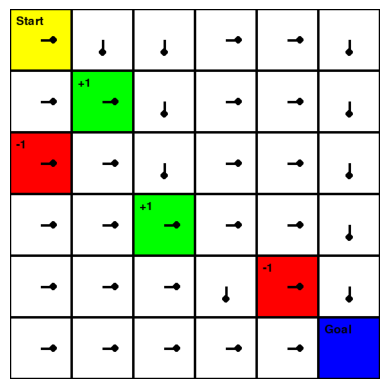

In [ ]:
import numpy as np
import pygame
from PIL import Image
from pyvirtualdisplay import Display
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SETUP VIRTUAL DISPLAY (for running Pygame in Google Colab)
# ------------------------------------------------------------
display = Display(visible=0, size=(800, 600))
display.start()

# ------------------------------------------------------------
# ENVIRONMENT (MDP) SETTINGS
# ------------------------------------------------------------
ROWS, COLS = 6, 6                 # Grid size → defines state space S
CELL_SIZE = 100                   # Size of each grid cell (visualization)
SCREEN_WIDTH = COLS * CELL_SIZE
SCREEN_HEIGHT = ROWS * CELL_SIZE

DISCOUNT_FACTOR = 0.9             # γ (gamma) → discount factor in Bellman equations
THRESHOLD = 1e-4                  # Convergence threshold for policy evaluation

# ------------------------------------------------------------
# COLORS (used only for visualization)
# ------------------------------------------------------------
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GREEN = (0, 255, 0)
RED   = (255, 0, 0)
BLUE  = (0, 0, 255)
GREY  = (200, 200, 200)

# ------------------------------------------------------------
# ACTION SPACE A
# Each action moves agent in the grid:
# Left, Right, Up, Down
# ------------------------------------------------------------
ACTIONS = [(0, -1), (0, 1), (-1, 0), (1, 0)]

# Arrow directions for drawing policy arrows on grid
ARROWS = [(-20, 0), (20, 0), (0, -20), (0, 20)]

# ------------------------------------------------------------
# DEFINE REWARD STRUCTURE AND TERMINAL STATE
# ------------------------------------------------------------
reward_positions  = [(1, 1), (3, 2)]   # +1 reward states
penalty_positions = [(2, 0), (4, 4)]   # -1 penalty states
goal_position     = (5, 5)             # Terminal goal state (+10 reward)
start_position    = (0, 0)             # Starting state

# ------------------------------------------------------------
# INITIALIZE MAZE (Reward Function R)
# ------------------------------------------------------------
maze = np.zeros((ROWS, COLS))          # Default reward = 0

for pos in reward_positions:
    maze[pos] = 1                      # Assign +1 rewards

for pos in penalty_positions:
    maze[pos] = -1                     # Assign -1 penalties

maze[goal_position] = 10               # Assign goal reward

# ------------------------------------------------------------
# INITIALIZE POLICY π(s) AND VALUE FUNCTION V(s)
# ------------------------------------------------------------
policy = np.zeros((ROWS, COLS), dtype=int)  # Start with arbitrary policy (all zeros)
V = np.zeros((ROWS, COLS))                  # Initialize value function to zero

# ------------------------------------------------------------
# CHECK IF A STATE IS WITHIN GRID BOUNDARY
# ------------------------------------------------------------
def is_valid_state(state):
    x, y = state
    return 0 <= x < ROWS and 0 <= y < COLS

# ------------------------------------------------------------
# TRANSITION FUNCTION P(s'|s,a)
# Deterministic transition: moves agent unless boundary reached
# ------------------------------------------------------------
def get_next_state(state, action):
    x, y = state
    dx, dy = action
    next_state = (x + dx, y + dy)
    return next_state if is_valid_state(next_state) else state

# ------------------------------------------------------------
# POLICY EVALUATION STEP
# Computes Vπ(s) using Bellman Expectation Equation:
#
# V(s) = R(s,π(s),s') + γ * V(s')
#
# Iterates until values converge below threshold
# ------------------------------------------------------------
def policy_evaluation(V, policy):
    while True:
        delta = 0
        for x in range(ROWS):
            for y in range(COLS):
                state = (x, y)

                # Skip terminal state update
                if state == goal_position:
                    continue

                # Take action dictated by current policy
                action = policy[state]
                next_state = get_next_state(state, ACTIONS[action])

                reward = maze[next_state]
                value = reward + DISCOUNT_FACTOR * V[next_state]

                # Track maximum value change for convergence
                delta = max(delta, abs(value - V[x, y]))
                V[x, y] = value

        # Stop evaluation when change is very small
        if delta < THRESHOLD:
            break

    return V

# ------------------------------------------------------------
# POLICY IMPROVEMENT STEP
# Updates policy using Bellman Optimality Equation:
#
# π_new(s) = argmax_a [ R(s,a,s') + γ * V(s') ]
#
# Returns updated policy and stability flag
# ------------------------------------------------------------
def policy_improvement(V, policy):
    policy_stable = True

    for x in range(ROWS):
        for y in range(COLS):
            state = (x, y)

            # Skip terminal state
            if state == goal_position:
                continue

            action_values = []

            # Compute action-value for each possible action
            for action in range(len(ACTIONS)):
                next_state = get_next_state(state, ACTIONS[action])
                reward = maze[next_state]
                value = reward + DISCOUNT_FACTOR * V[next_state]
                action_values.append(value)

            # Select best action
            best_action = np.argmax(action_values)

            # Check if policy changed
            if best_action != policy[x, y]:
                policy_stable = False

            policy[x, y] = best_action

    return policy, policy_stable

# ------------------------------------------------------------
# POLICY ITERATION ALGORITHM
# Alternates between policy evaluation and improvement
# until policy becomes stable (optimal)
# ------------------------------------------------------------
def policy_iteration():
    global V, policy

    while True:
        V = policy_evaluation(V, policy)          # Evaluate current policy
        policy, stable = policy_improvement(V, policy)  # Improve policy

        if stable:                               # Stop if optimal policy reached
            break

    return policy, V

# ------------------------------------------------------------
# FIND OPTIMAL PATH FROM START TO GOAL USING FINAL POLICY
# ------------------------------------------------------------
def find_optimal_path(policy):
    path = []
    state = start_position

    while state != goal_position:
        path.append(state)
        action = ACTIONS[policy[state]]
        state = get_next_state(state, action)

    path.append(goal_position)
    return path

# ------------------------------------------------------------
# DRAW ARROWS REPRESENTING POLICY ACTIONS
# ------------------------------------------------------------
def draw_arrow(screen, pos, direction):
    x, y = pos
    start_x = y * CELL_SIZE + CELL_SIZE // 2
    start_y = x * CELL_SIZE + CELL_SIZE // 2
    dx, dy = direction
    end_x = start_x + dx
    end_y = start_y + dy

    pygame.draw.line(screen, BLACK, (start_x, start_y), (end_x, end_y), 4)
    pygame.draw.circle(screen, BLACK, (end_x, end_y), 6)

# ------------------------------------------------------------
# DRAW GRID WORLD WITH REWARDS, START, GOAL AND POLICY ARROWS
# ------------------------------------------------------------
def draw_maze(screen, policy, optimal_path):
    screen.fill(WHITE)
    font = pygame.font.SysFont(None, 28)

    for x in range(ROWS):
        for y in range(COLS):
            rect_x, rect_y = y * CELL_SIZE, x * CELL_SIZE

            # Draw grid cell border
            pygame.draw.rect(screen, GREY, (rect_x, rect_y, CELL_SIZE, CELL_SIZE))
            pygame.draw.rect(screen, BLACK, (rect_x, rect_y, CELL_SIZE, CELL_SIZE), 2)

            # Color special states
            if (x, y) == start_position:
                color = (255, 255, 0)  # Start state
                text = "Start"
            elif (x, y) == goal_position:
                color = BLUE           # Goal state
                text = "Goal"
            elif maze[x, y] == 1:
                color = GREEN          # Reward state
                text = "+1"
            elif maze[x, y] == -1:
                color = RED            # Penalty state
                text = "-1"
            else:
                color = WHITE           # Normal state
                text = ""

            pygame.draw.rect(screen, color, (rect_x + 2, rect_y + 2, CELL_SIZE - 4, CELL_SIZE - 4))
            text_surface = font.render(text, True, BLACK)
            screen.blit(text_surface, (rect_x + 10, rect_y + 10))

            # Draw policy arrow (except in terminal state)
            if (x, y) != goal_position:
                action = policy[x, y]
                arrow_dir = ARROWS[action]
                draw_arrow(screen, (x, y), arrow_dir)

    pygame.display.flip()

# ------------------------------------------------------------
# MAIN FUNCTION
# Runs Policy Iteration and Displays Optimal Policy
# ------------------------------------------------------------
def main():
    pygame.init()
    screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
    pygame.display.set_caption("Maze Game with Policy Iteration")

    global V, policy
    policy, V = policy_iteration()     # Compute optimal policy π* and value V*

    optimal_path = find_optimal_path(policy)  # (Optional) compute path from start to goal

    draw_maze(screen, policy, optimal_path)   # Display policy arrows
    pygame.image.save(screen, "maze_optimal_policy.png")

    pygame.quit()

# Run program
main()

# ------------------------------------------------------------
# DISPLAY OUTPUT IMAGE INSIDE COLAB
# ------------------------------------------------------------
img = Image.open("maze_optimal_policy.png")
plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
# !apt-get install -y xvfb python-opengl
# !pip install pygame
# !xvfb-run -s "-screen 0 1024x768x24" python your_script.py

In [ ]:
# from pyvirtualdisplay import Display
# display = Display(visible=0, size=(1024,768))
# display.start()


In [ ]:
# your pygame code here
# main()


In [ ]:
# from PIL import Image
# import matplotlib.pyplot as plt

# img = Image.open("maze_optimal_policy.png")
# plt.imshow(img)
# plt.axis('off')
